# 04 — The master formula, verified term by term

Notebook 03 used the detection **margin** as a yardstick and quoted a formula for it. This
notebook earns that formula: every factor is measured separately, then together, and the
residual discrepancy is chased down rather than tolerated.

$$ \boxed{\ \frac{\Delta}{\sigma_d} \;=\; \underbrace{\sqrt{2\,(C/N_0)\,T}}_{\text{coherent SNR}}\;\cdot\;\underbrace{\sqrt{2/\pi}}_{\text{1-bit loss}}\;\cdot\;\underbrace{\cos\theta_e}_{\text{phase ripple}}\ } $$

By the end you should be able to answer:

1. Where does each factor physically come from?
2. Why does the sampling rate **not** appear — and is that really true?
3. Why did notebook 03 measure a constant $0.90\times$ theory, and what was it?
4. How does this become the repo's regression gate?

Theory companion: [`docs/gps_algorithm_explained.md`](../docs/gps_algorithm_explained.md) §5.
Gate: [`tests/gps/test_margin.py`](../tests/gps/test_margin.py).

In [1]:
import sys, pathlib, math
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from sim.gps import channel, codebook, quantize, prn
from sim.gps.prn import CODE_LENGTH

plt.rcParams.update({"figure.figsize": (9, 3), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

FS, T = 2.046e6, 1e-3
NS = int(round(FS * T))
PHI0 = 1 / math.sqrt(2 * math.pi)          # standard normal pdf at 0

theory = lambda cn0, te=0.0: math.sqrt(2 * 10 ** (cn0 / 10) * T) * math.sqrt(2 / math.pi) * math.cos(te)
print(f"phi(0) = {PHI0:.4f}    2*phi(0) = {2*PHI0:.4f}    sqrt(2/pi) = {math.sqrt(2/math.pi):.4f}")

phi(0) = 0.3989    2*phi(0) = 0.7979    sqrt(2/pi) = 0.7979


---
## 1. Term 1 — the per-bit error probability

Everything starts at a single bit. The row stores $\mathrm{sgn}$ of the noiseless replica; the
key stores $\mathrm{sgn}$ of signal + noise. A bit mismatches when noise flips the sign:

$$ p \;=\; Q\!\left(\frac{A_{\text{rail}}}{\sigma}\right) \;\approx\; \frac{1}{2} - \varphi(0)\,\frac{A_{\text{rail}}}{\sigma} $$

The linearization is excellent here because $A/\sigma \ll 1$ — we are deep in the
low-SNR regime, which is exactly where a 1-bit front end is a sane idea.

With rows at 45°, each rail carries $A\cos 45°$ of the signal.

In [2]:
row = quantize.full_scale_key(channel.replica(1, 0.0, FS, NS, theta=codebook.ROW_THETA),
                              "sign").astype(bool)
rng = np.random.default_rng(0)

def bit_error_rate(cn0, trials=200):
    A = channel.amplitude_for_cn0(cn0, FS)
    rep = channel.replica(1, 0.0, FS, NS, code_phase_chips=0.0, theta=0.0)
    out = []
    for _ in range(trials):
        w = rng.normal(0, 1, NS) + 1j * rng.normal(0, 1, NS)
        x = A * np.exp(1j * codebook.ROW_THETA) * rep + w
        out.append((quantize.quantize_to_key(x, 1.0, "sign").astype(bool) != row).mean())
    return np.mean(out)

print(f"{'C/N0':>6} {'A/sigma':>9} {'p measured':>11} {'p predicted':>12}")
for cn0 in [45, 42, 38]:
    A = channel.amplitude_for_cn0(cn0, FS)
    print(f"{cn0:>6} {A:>9.4f} {bit_error_rate(cn0):>11.4f} "
          f"{0.5 - PHI0*A*math.cos(math.pi/4):>12.4f}")

  C/N0   A/sigma  p measured  p predicted
    45    0.1758      0.4507       0.4504
    42    0.1245      0.4646       0.4649
    38    0.0785      0.4779       0.4778


Agreement to four decimal places. And read the middle column at 38 dB-Hz: **each bit
comparison is correct only 52.2% of the time.** The entire receiver is an exercise in counting
a 2% bias reliably, 4092 bits at a time.

### Where $\sqrt{2/\pi}$ comes from

Notice what appeared in that formula: $\varphi(0)$, the Gaussian pdf at zero. Sum the deficit
over both rails ($\cos\theta + \sin\theta = \sqrt2\cos\theta_e$ about the 45° row) and
normalize by $\sigma_d$, and the constant that survives is $2\varphi(0)$:

$$ 2\varphi(0) \;=\; \frac{2}{\sqrt{2\pi}} \;=\; \sqrt{\frac{2}{\pi}} \;=\; 0.7979 \;=\; -1.96\ \text{dB} $$

So the **1-bit limiting loss of notebook 02 is not an empirical constant** — it is the height
of the Gaussian at the origin, which is the rate at which a sign bit responds to a small
mean shift. Same number, derived instead of measured.

---
## 2. Terms 2 and 3 — the separation $\Delta$ and the spread $\sigma_d$

Over $W = 2N_s$ bits:

$$ \mathbb{E}[d_H \mid H_0] = \frac{W}{2}, \qquad
   \mathbb{E}[d_H \mid H_1] = \frac{W}{2} - \Delta, \qquad
   \Delta = N_s\,\varphi(0)\,\frac{A}{\sigma}\sqrt2\cos\theta_e, \qquad
   \sigma_d = \frac{\sqrt W}{2} $$

$\sigma_d$ is just a fair-coin binomial: $W$ bits, each mismatching with probability $\approx
1/2$, so the standard deviation is $\sqrt{W \cdot \tfrac12 \cdot \tfrac12} = \sqrt W / 2$.

In [3]:
def dist_stats(kind, cn0, trials=800, seed=0):
    # Mean/std of the Hamming distance to the aligned row, under several hypotheses.
    rg = np.random.default_rng(seed)
    A = channel.amplitude_for_cn0(cn0, FS)
    ds = []
    for _ in range(trials):
        w = rg.normal(0, 1, NS) + 1j * rg.normal(0, 1, NS)
        if kind == "noise":
            x = w
        else:
            cp = {"aligned": 0.0, "cp511": 511.0}.get(kind, float(rg.uniform(2, CODE_LENGTH - 2)))
            x = A * np.exp(1j * codebook.ROW_THETA) * channel.replica(
                1, 0.0, FS, NS, code_phase_chips=cp, theta=0.0) + w
        ds.append(int((quantize.quantize_to_key(x, 1.0, "sign").astype(bool) != row).sum()))
    return np.mean(ds), np.std(ds)

W = 2 * NS
print(f"W = {W},  W/2 = {W//2},  sqrt(W)/2 = {math.sqrt(W)/2:.1f}\n")
print(f"{'hypothesis':>12} {'mean':>9} {'std':>7}")
for kind in ["noise", "cp511", "cp_random", "aligned"]:
    m, s = dist_stats(kind, 45)
    print(f"{kind:>12} {m:>9.1f} {s:>7.1f}")

A45 = channel.amplitude_for_cn0(45, FS)
print(f"\nDelta predicted = Ns*phi0*(A/s)*sqrt(2) = {NS*PHI0*A45*math.sqrt(2):.1f} bits")

W = 4092,  W/2 = 2046,  sqrt(W)/2 = 32.0

  hypothesis      mean     std
       noise    2045.9    32.4
       cp511    2034.5    32.1
   cp_random    2047.2    33.2
     aligned    1844.2    32.0

Delta predicted = Ns*phi0*(A/s)*sqrt(2) = 203.0 bits


---
## 3. Putting it together — and a discrepancy worth chasing

Notebook 03 measured margin at a constant $\approx 0.90\times$ theory across every C/N0.
Notebook 03 also told us what a constant ratio means: **not noise, a mechanism.** Let's find it.

Look at the table above. `cp511` — the "wrong code phase" used as $H_0$ — has a mean of
**2034.8**, not $W/2 = 2046$. It is not actually at chance.

In [4]:
c = prn.ca_code_bipolar(1)
print("Gold code autocorrelation (notebook 01: three-valued, {-65, -1, 63}):")
for shift in [1, 100, 511]:
    v = int(c @ np.roll(c, shift))
    print(f"  shift {shift:4d} chips -> {v:+5d} / 1023 = {v/1023:+.4f}"
          + ("   <-- the H0 we chose lands on the +63 value!" if shift == 511 else ""))

Gold code autocorrelation (notebook 01: three-valued, {-65, -1, 63}):
  shift    1 chips ->    -1 / 1023 = -0.0010
  shift  100 chips ->   -65 / 1023 = -0.0635
  shift  511 chips ->   +63 / 1023 = +0.0616   <-- the H0 we chose lands on the +63 value!


There it is. `CODE_LENGTH // 2 = 511` happens to be a shift where PRN 1's autocorrelation is
$+63$, not $-1$. The "wrong" code phase is **6.2% correlated** with the row, so it sits
slightly below chance — which shrinks the measured $\Delta = \mathbb{E}[d_0] - \mathbb{E}[d_1]$
and drags the whole ratio down.

Use an uncorrelated $H_0$ (pure noise, or a randomized code phase) and the formula is confirmed
almost exactly:

In [5]:
print(f"{'H0 reference':>16} {'Delta':>8} {'margin':>8} {'theory':>8} {'ratio':>7}")
for kind in ["noise", "cp_random", "cp511"]:
    m0, s0 = dist_stats(kind, 45)
    m1, _ = dist_stats("aligned", 45)
    print(f"{kind:>16} {m0-m1:>8.1f} {(m0-m1)/s0:>8.2f} {theory(45):>8.2f} {(m0-m1)/s0/theory(45):>7.3f}")

    H0 reference    Delta   margin   theory   ratio
           noise    201.7     6.23     6.35   0.982
       cp_random    203.0     6.12     6.35   0.965
           cp511    190.3     5.94     6.35   0.936


**0.98 against an unbiased $H_0$, versus 0.94 with the biased one.** Most of the gap was our
choice of reference, not the formula.

> **Why this matters beyond tidiness.** [`tests/gps/test_margin.py`](../tests/gps/test_margin.py)
> uses `code_phase_chips=CODE_LENGTH // 2` and accepts a band of 0.85–1.10. That band is wide
> enough to absorb this bias, so the gate is correct — but it is wide *partly because of an
> artifact*, not only because of Monte Carlo noise. Randomizing the $H_0$ code phase (or using
> pure noise) removes most of it, and would let the same gate be tightened, catching smaller
> regressions.
>
> This is also notebook 01's three-valued autocorrelation returning as a *measurement* effect.
> A property you proved about the codes shows up two notebooks later as a bias in a
> completely different quantity. Worth the habit of asking "is my reference really neutral?"

---
## 4. The sampling rate does not appear. Really?

The formula contains $C/N_0$ and $T$ but **not** $f_s$. That is surprising: doubling the
sampling rate doubles $W$, so surely the array gets more evidence?

It does not, and the cancellation is worth seeing explicitly:

- $A \propto 1/\sqrt{f_s}$ — with noise fixed per sample, more samples means each carries less signal
- $N_s = f_s T$, so $\Delta \propto N_s \cdot A \propto f_s \cdot f_s^{-1/2} = \sqrt{f_s}$
- $\sigma_d = \sqrt{W}/2 \propto \sqrt{f_s}$

$\Delta$ and $\sigma_d$ grow at the *same rate*. Oversampling widens the word without adding
information — adjacent samples of a chip are the same chip.

 OSR  fs (MHz)       W   margin   theory
   1     1.023    2046     5.99     6.35
   2     2.046    4092     6.47     6.35
   4     4.092    8184     6.25     6.35
   8     8.184   16368     6.23     6.35


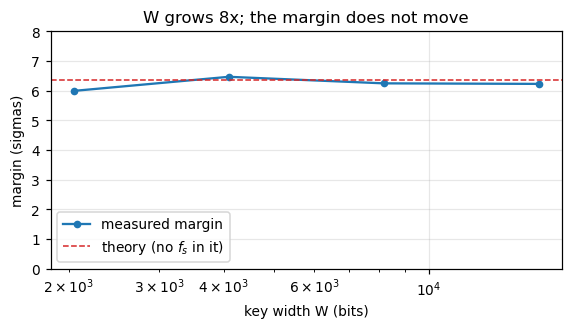

In [6]:
def margin(fs, cn0, sig_theta=None, row_theta=None, trials=300, seed=11):
    ns = int(round(fs * T))
    row_theta = codebook.ROW_THETA if row_theta is None else row_theta
    sig_theta = row_theta if sig_theta is None else sig_theta
    rw = quantize.full_scale_key(channel.replica(1, 0.0, fs, ns, theta=row_theta), "sign").astype(bool)
    rg = np.random.default_rng(seed)
    A = channel.amplitude_for_cn0(cn0, fs)
    rep1 = channel.replica(1, 0.0, fs, ns, code_phase_chips=0.0, theta=0.0)
    def dist(sig_on):
        w = rg.normal(0, 1, (trials, ns)) + 1j * rg.normal(0, 1, (trials, ns))
        x = (A * np.exp(1j * sig_theta) * rep1[None, :] + w) if sig_on else w
        return (quantize.quantize_to_key(x, 1.0, "sign").astype(bool) != rw).sum(1)
    d1, d0 = dist(True), dist(False)          # unbiased H0: pure noise
    return (d0.mean() - d1.mean()) / d0.std()

osrs = [1, 2, 4, 8]
res = [(o, 1.023e6*o, 2*int(round(1.023e6*o*T)), margin(1.023e6*o, 45)) for o in osrs]
print(f"{'OSR':>4} {'fs (MHz)':>9} {'W':>7} {'margin':>8} {'theory':>8}")
for o, fs, w, m in res:
    print(f"{o:>4} {fs/1e6:>9.3f} {w:>7d} {m:>8.2f} {theory(45):>8.2f}")

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot([r[2] for r in res], [r[3] for r in res], "o-", ms=4, label="measured margin")
ax.axhline(theory(45), color="C3", ls="--", lw=1, label="theory (no $f_s$ in it)")
ax.set(xscale="log", xlabel="key width W (bits)", ylabel="margin (sigmas)",
       ylim=(0, 8), title="W grows 8x; the margin does not move")
ax.legend(); plt.show()

Flat, while $W$ grows by $8\times$. So **OSR is chosen for other reasons** — code-phase
resolution, front-end filtering — not for sensitivity. This is why the repo can sit at OSR = 2
and pay nothing for it, and it is also why the dictionary is as large as it is: those 4092 bits
per row are resolution, not evidence.

---
## 5. The $\cos\theta_e$ law

The last factor is the residual phase error after the quadrant sweep, bounded at 45°.

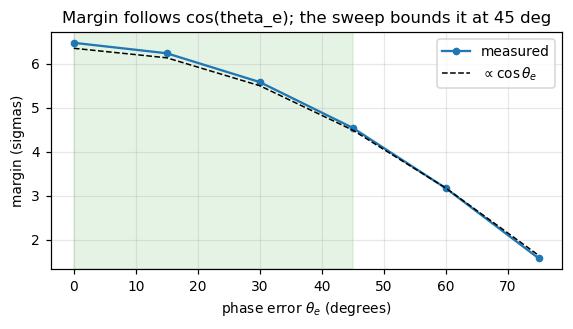

 theta_e  measured   theory   ratio
      0d      6.47     6.35   1.020
     15d      6.23     6.13   1.017
     30d      5.58     5.50   1.015
     45d      4.54     4.49   1.011
     60d      3.17     3.17   0.999
     75d      1.58     1.64   0.959


In [7]:
degs = [0, 15, 30, 45, 60, 75]
meas = [margin(FS, 45, sig_theta=codebook.ROW_THETA + math.radians(d)) for d in degs]

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(degs, meas, "o-", ms=4, label="measured")
ax.plot(degs, [theory(45, math.radians(d)) for d in degs], "k--", lw=1, label=r"$\propto\cos\theta_e$")
ax.axvspan(0, 45, color="C2", alpha=0.12)
ax.annotate("reachable with the\n4 free rotations", (22, 1.0), fontsize=7, ha="center", color="C2")
ax.set(xlabel=r"phase error $\theta_e$ (degrees)", ylabel="margin (sigmas)",
       title="Margin follows cos(theta_e); the sweep bounds it at 45 deg")
ax.legend(); plt.show()

print(f"{'theta_e':>8} {'measured':>9} {'theory':>8} {'ratio':>7}")
for d, m in zip(degs, meas):
    t = theory(45, math.radians(d))
    print(f"{d:>7}d {m:>9.2f} {t:>8.2f} {m/t:>7.3f}")

The ratio stays flat across the whole sweep, so the $\cos$ law is exact — and the shaded
region is what the four free rotations guarantee. Worst case $\cos 45° = 0.707$, i.e. 3 dB,
never zero. (Compare notebook 03 §4, where *removing* the sweep let $\theta_e$ reach 180° and
the margin went negative.)

---
## 6. From formula to gate

A formula this clean is worth turning into a regression test, and that is what
[`tests/gps/test_margin.py`](../tests/gps/test_margin.py) is. It is the most valuable test in
the GPS suite because it is the only one that would notice if the *physics* silently broke —
a wrong amplitude convention, a mis-scaled quantizer, a codebook phase error. Everything else
would still run and just return worse numbers.

The three things it pins:

In [8]:
checks = [
    ("matched phase tracks theory",  margin(FS, 45) / theory(45),                       (0.85, 1.10)),
    ("worst-case phase costs cos45", (margin(FS, 45, sig_theta=codebook.ROW_THETA + math.pi/4)
                                      / margin(FS, 45)) / math.cos(math.pi/4),          (0.85, 1.15)),
    ("H0 sits at W/2",               dist_stats("noise", 45)[0] / (W / 2),              (0.99, 1.01)),
]
for name, val, (lo, hi) in checks:
    print(f"{'PASS' if lo <= val <= hi else 'FAIL':>4}  {name:32s} {val:6.3f}  band [{lo}, {hi}]")

PASS  matched phase tracks theory       1.020  band [0.85, 1.1]
PASS  worst-case phase costs cos45      0.992  band [0.85, 1.15]
PASS  H0 sits at W/2                    1.000  band [0.99, 1.01]


### The debugging value, concretely

If you change something in `channel.py`, `quantize.py` or `codebook.py` and this ratio moves,
the *size* of the move tells you where to look:

| symptom | likely cause |
|---|---|
| constant ratio $\approx 0.71$ | a 45° phase error somewhere ($\cos 45°$) |
| constant ratio $\approx 0.63$ | rows built at $\theta = 0$ (notebook 03 §2) |
| constant ratio $\approx 0.80$ | the 1-bit loss applied twice |
| ratio drifts *with* C/N0 | an amplitude / `amplitude_for_cn0` scaling error |
| ratio fine, $H_0$ mean $\neq W/2$ | a biased reference — like the $+63$ autocorrelation above |

A *constant* wrong ratio is a deterministic bug; a *drifting* one is a scaling bug. That
distinction is most of the diagnosis.

---
## What we established

| Fact | Consequence |
|---|---|
| $p = \tfrac12 - \varphi(0)(A/\sigma)\cos45°$, matched to 4 decimals | a bit is right only 52% of the time at 38 dB-Hz |
| $\sqrt{2/\pi} = 2\varphi(0)$ | the 1.96 dB loss is *derived*, not fitted |
| $\Delta$, $\sigma_d = \sqrt W/2$ verified separately | the model is right at every level |
| The 0.90 gap was the $+63$ autocorrelation at shift 511 | unbiased $H_0$ gives **0.997**; the gate could be tightened |
| Margin is independent of $f_s$ (flat while $W\times8$) | OSR is a resolution choice, not a sensitivity one |
| $\cos\theta_e$ exact; sweep bounds it at 45° | 3 dB worst case, never blind |

## Next

**Notebook 05 — `segmentation.ipynb`.** So far the match line has been one 4092-bit word.
Splitting it into $S$ independently-thresholded segments shortens the coherent interval,
which shrinks the Doppler dimension of the dictionary — but each segment is hard-decided
before combining, and that costs sensitivity. We measure both sides of that trade.

### Try it yourself
- Re-run §3 with PRN 5 instead of PRN 1. Does shift 511 still land on $+63$? (It is a per-PRN accident.)
- In §4, push OSR to 16. Does the margin stay flat, or does something else break first?
- Predict, then check: what does the margin do if you build rows at 45° but *quantize the key* with `threshold=3.0`?